# CẢI TIẾN MÔ HÌNH DỮ LIỆU QUAN HỆ PIZZA RUNNER

## 1. PHÂN TÍCH VẤN ĐỀ

In [ ]:
from IPython.display import Image, display

Trong giai đoạn tiền xử lý dữ liệu ở WEEK02, quy trình làm sạch và chuẩn hóa dữ liệu thô đã được thực hiện qua các bước:

* Tạo schema staging và destination.

* Nhập dữ liệu thô vào các bảng staging.

* Đối chiếu với các nguyên tắc dữ liệu quan hệ để phát hiện điểm chưa phù hợp.

* Làm sạch, chuẩn hóa dữ liệu rồi lưu vào bảng tạm.

* Tạo bảng đích trong schema destination, đổ dữ liệu và thiết lập khóa ngoại.


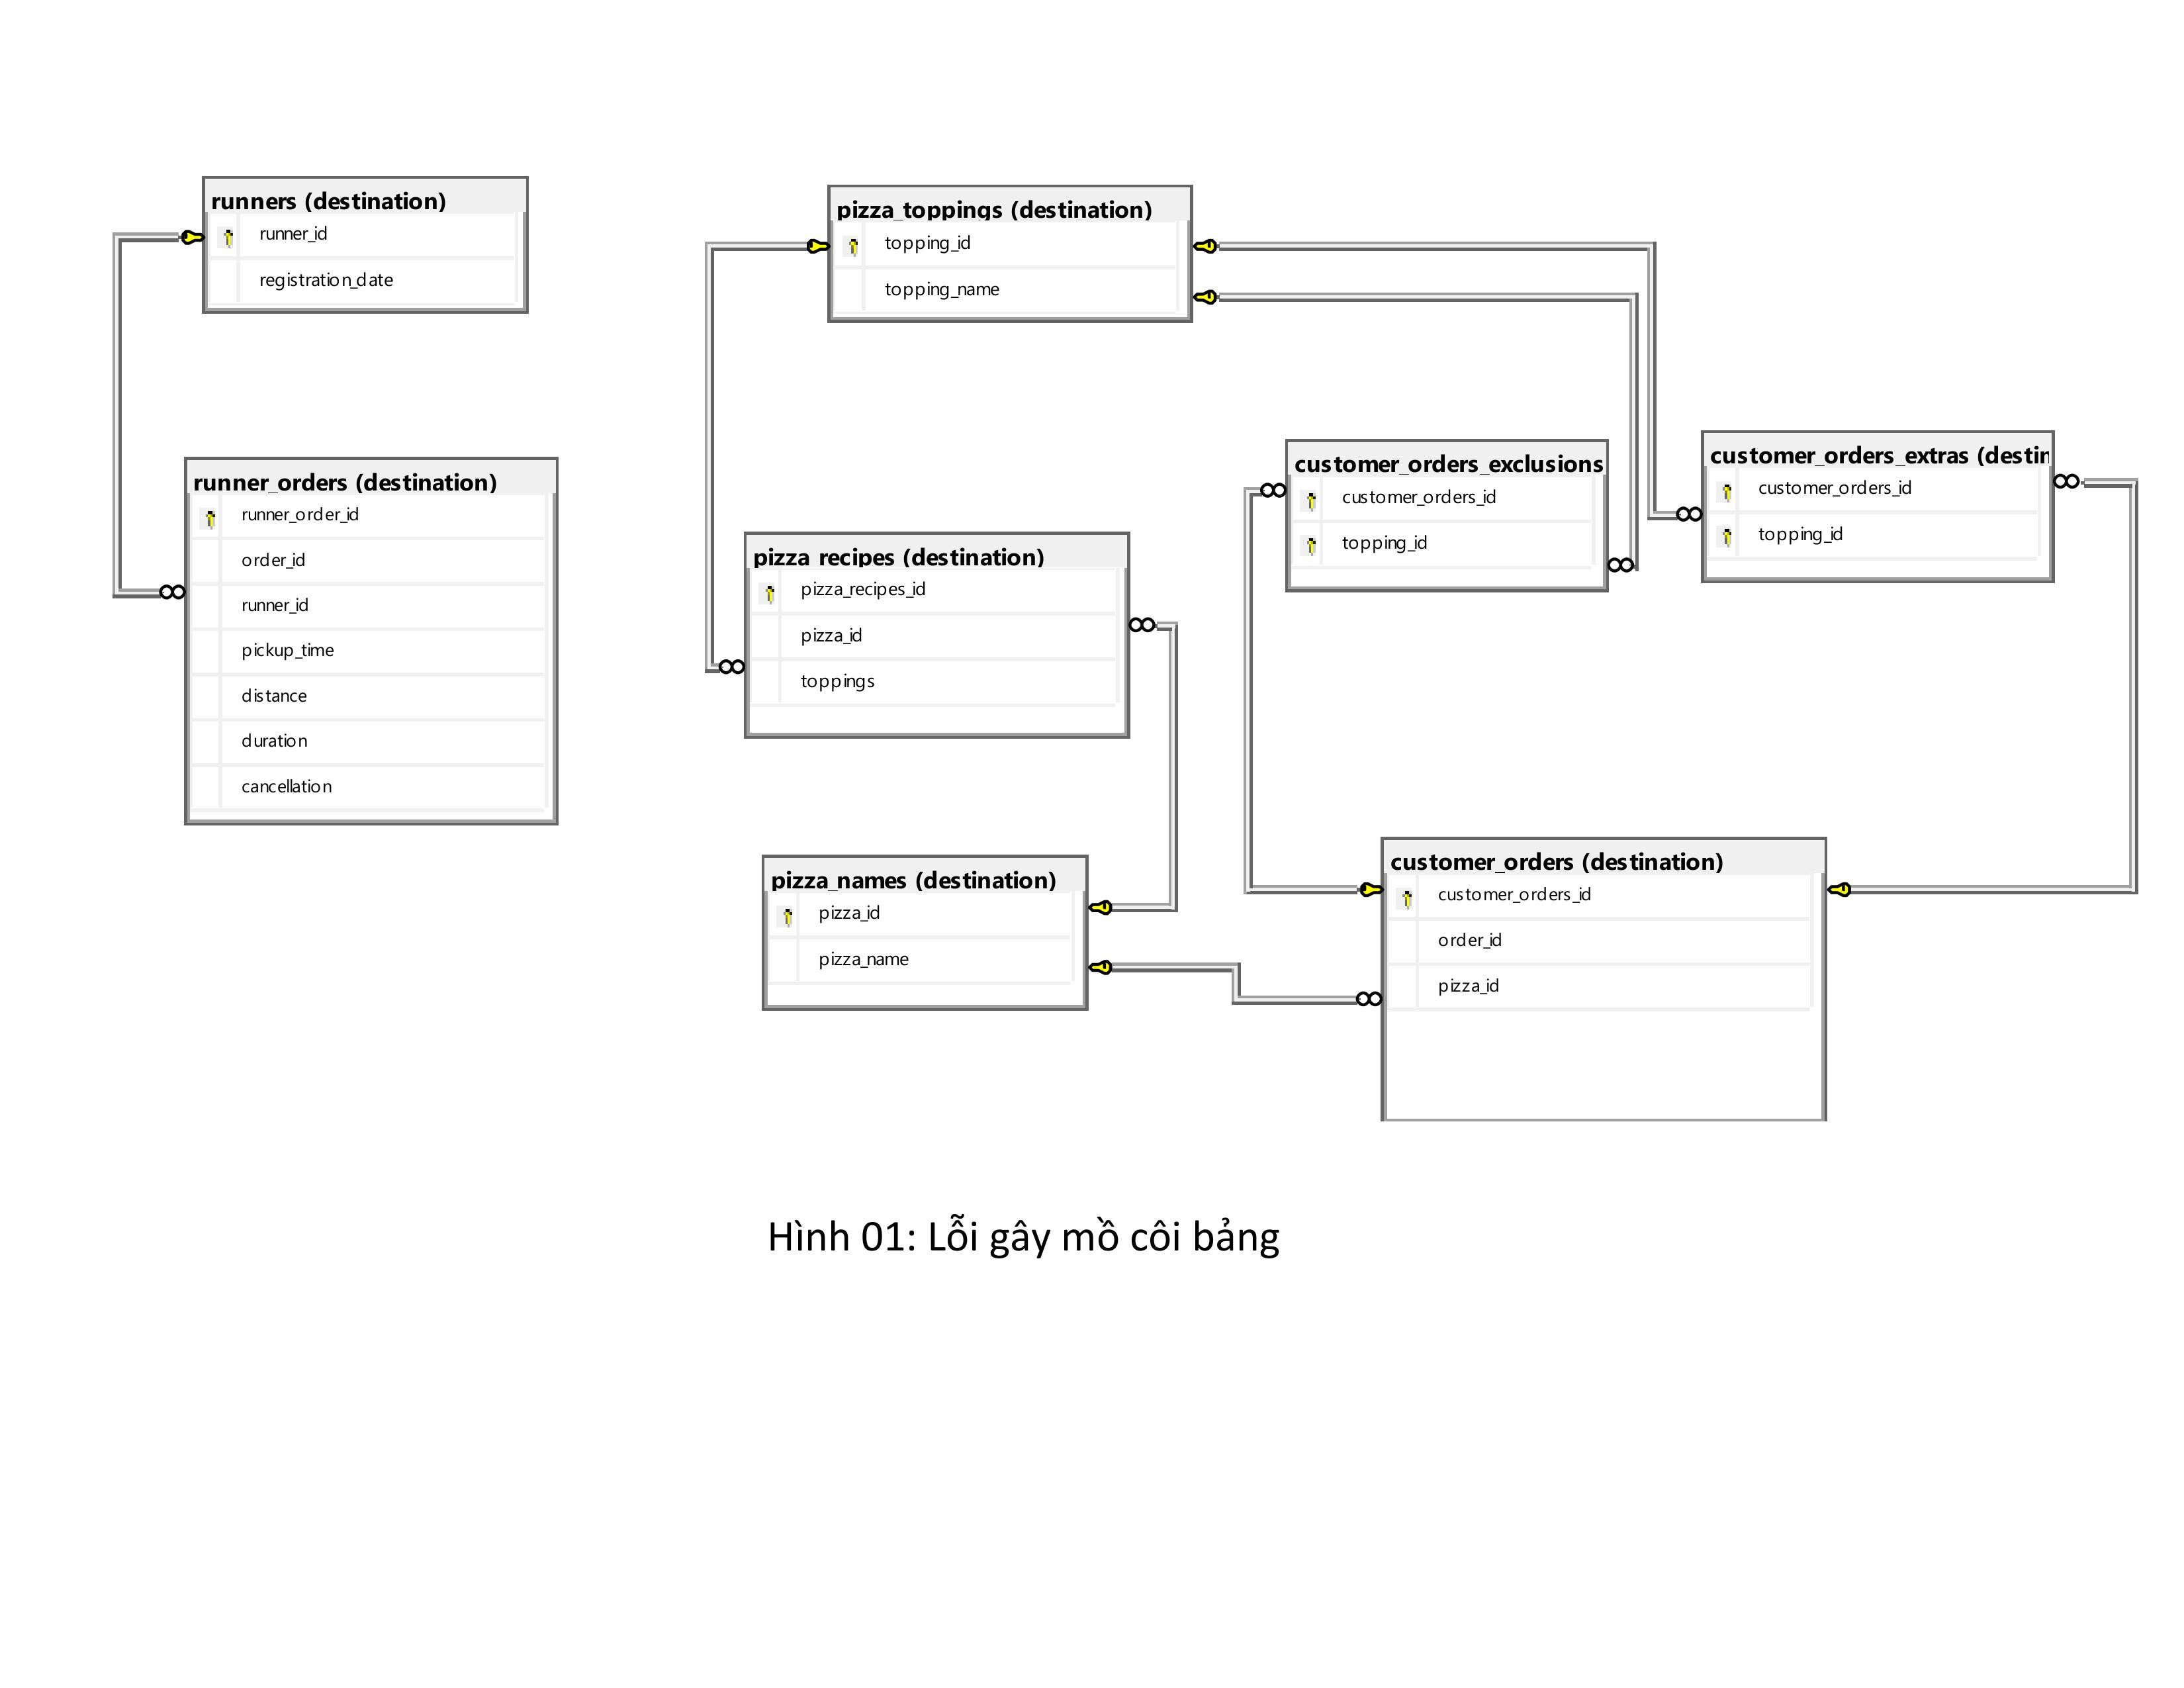

In [ ]:
display(Image('/content/01_erd_loi_mo_coi.jpg'))


Tuy nhiên, sơ đồ quan hệ (Hình 1) cho thấy một hạn chế:

  * Bảng mồ côi: Khối “vận chuyển” (runner_orders, runners) gần như biệt lập với khối “bán hàng” và “nhà bếp”.

Bên cạnh hạn chế, khóa ngoại hiện đã:

  * Tối ưu cho truy vấn: Các quan hệ extras và exclusions nối tới pizza_toppings hỗ trợ tốt các câu hỏi phân tích như tính giá bán (vì giá có thể biến động theo topping thêm vào).

  * Thể hiện được logic thiết kế  dựa trên luồng kinh doanh tự nhiên: một đơn hàng (orders) chứa nhiều dòng sản phẩm (customer_orders), mỗi sản phẩm nằm trong danh mục (pizza_names) và có công thức (pizza_recipes), được phép thêm/bớt topping (extras, exclusions).

## 2. GIẢI PHÁP THIẾT KẾ

Để giải quyết tình trạng mồ côi và tối ưu khóa ngoại, cần tạo một bảng `orders` đóng vai trò thực thể trung tâm, chứa thông tin cốt lõi của mỗi đơn hàng (`order_id`, `customer_id`, `order_time`). Từ đó:
- Liên kết `customer_orders` với `orders` qua `order_id`.
- Liên kết `runner_orders` với `orders` qua `order_id`, giúp khối vận chuyển không còn tách rời.
- Giữ nguyên liên kết giữa `customer_orders` với danh mục pizza và công thức, đồng thời bảo đảm các quan hệ về topping được nhất quán.

Do các bảng hiện tại đã có ràng buộc khóa ngoại, quy trình thực hiện sẽ tuân thủ thứ tự gỡ ràng buộc từ bảng ít phụ thuộc nhất đến bảng bị phụ thuộc nhiều nhất.

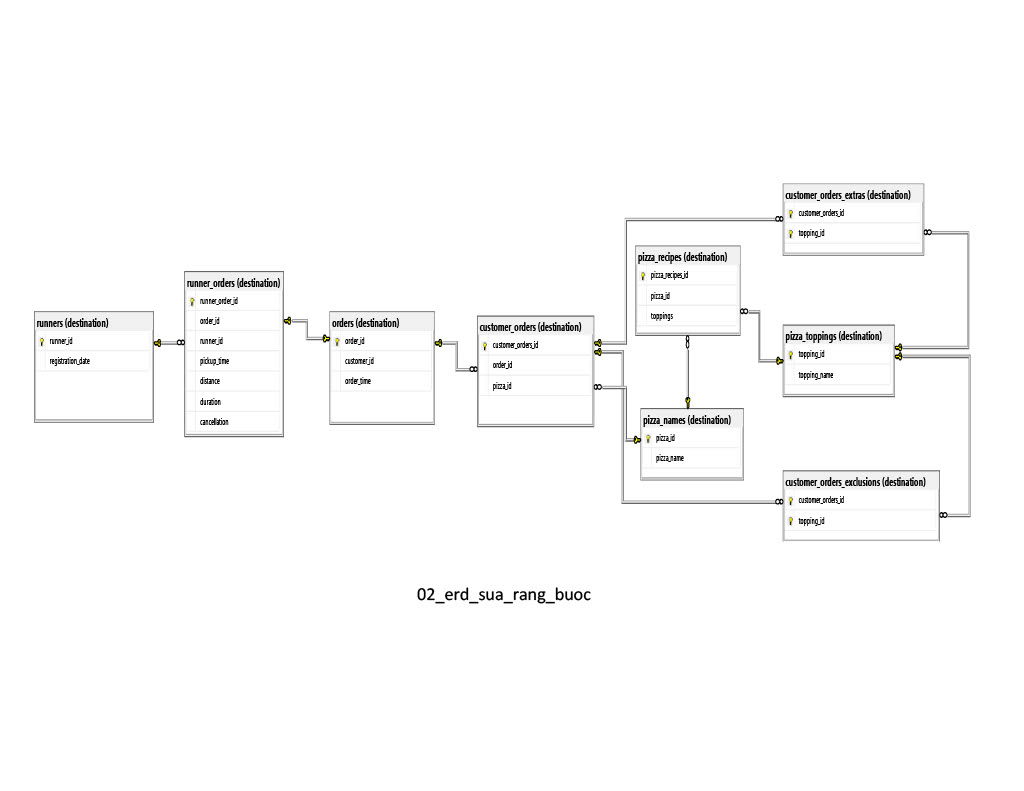

In [ ]:
display(Image('/content/02_erd_sua_rang_buoc.jpg'))

## 3. TRIỂN KHAI SQL

### 3.1. Chuẩn bị: gỡ ràng buộc và xóa bảng cũ

- Xóa ràng buộc từ các bảng con trước.
- Sau đó xóa bảng `customer_orders` để thiết kế lại.

In [ ]:
%sql
USE Pizza_Runner;

In [ ]:
%sql
ALTER TABLE destination.customer_orders_exclusions
  DROP CONSTRAINT fk_customer_orders_customer_orders_exclusions;

In [ ]:
%sql
ALTER TABLE destination.customer_orders_extras
  DROP CONSTRAINT fk_customer_orders_customer_orders_extras;

In [ ]:
%sql
DROP TABLE destination.customer_orders;

### 3.2. Tạo bảng **orders** mới

In [ ]:
%sql
CREATE TABLE destination.orders (
    order_id INT PRIMARY KEY,
    customer_id INT NOT NULL,
    order_time TIMESTAMP NOT NULL
);

### 3.3. Tạo lại **customer_orders** với khóa ngoại

In [ ]:
%sql
CREATE TABLE destination.customer_orders (
    customer_orders_id BIGINT GENERATED ALWAYS AS IDENTITY (START WITH 1 INCREMENT BY 1) PRIMARY KEY,
    order_id INT NOT NULL,
    pizza_id INT NOT NULL,
    CONSTRAINT fk_customer_orders_orders
        FOREIGN KEY (order_id) REFERENCES destination.orders(order_id) ,
    CONSTRAINT fk_customer_orders_pizza_names
        FOREIGN KEY (pizza_id) REFERENCES destination.pizza_names(pizza_id)
);

### 3.4. Thêm dữ liệu và phục hồi ràng buộc

Trước khi tạo ràng buộc, cần `INSERT` dữ liệu vào `orders` và `customer_orders` để đảm bảo tham chiếu hợp lệ.

In [ ]:
%sql
INSERT INTO destination.orders
			(order_id ,customer_id , order_time)
VALUES
			('1', '101', '2020-01-01 18:05:02'),
			('2', '101', '2020-01-01 19:00:52'),
			('3', '102', '2020-01-02 23:51:23'),
			('4', '103', '2020-01-04 13:23:46'),
			('5', '104', '2020-01-08 21:00:29'),
			('6', '101', '2020-01-08 21:03:13'),
			('7', '105', '2020-01-08 21:20:29'),
			('8', '102',  '2020-01-09 23:54:33'),
			('9', '103',  '2020-01-10 11:22:59'),
			('10', '104', '2020-01-11 18:34:49')

num_affected_rows,num_inserted_rows
10,10


In [ ]:
%sql
SELECT *
FROM destination.orders
LIMIT 5

order_id,customer_id,order_time
1,101,2020-01-01T18:05:02.000Z
2,101,2020-01-01T19:00:52.000Z
3,102,2020-01-02T23:51:23.000Z
4,103,2020-01-04T13:23:46.000Z
5,104,2020-01-08T21:00:29.000Z


In [ ]:
%sql
-- Insert dữ liệu vào bảng destinatiion.customer_orders
INSERT INTO destination.customer_orders
			(order_id ,pizza_id)
VALUES
			('1',  '1'),
			('2',  '1'),
			('3',  '1'),
			('3',  '2'),
			('4',  '1'),
			('4',  '1'),
			('4',  '2'),
			('5',  '1'),
			('6',  '2'),
			('7',  '2'),
			('8',  '1'),
			('9',  '1'),
			('10', '1'),
			('10', '1')

num_affected_rows,num_inserted_rows
14,14


In [ ]:
%sql
SELECT *
FROM destination.customer_orders
LIMIT 5

customer_orders_id,order_id,pizza_id
1,1,1
2,2,1
3,3,1
4,3,2
5,4,1


**Thiết lập ràng buộc cho `runner_orders`**
- Ràng buộc `UNIQUE` trên `order_id`: mỗi đơn hàng chỉ được giao bởi tối đa một runner, phù hợp với logic vận hành thực tế.
- Khóa ngoại trỏ tới `orders`: đảm bảo mọi bản ghi vận chuyển đều tham chiếu đến một đơn hàng tồn tại trong bảng `orders`, đồng thời kết nối hoàn chỉnh khối vận chuyển với trung tâm dữ liệu.

In [ ]:
%sql
ALTER TABLE destination.runner_orders
  ADD CONSTRAINT fk_runner_orders_orders
  FOREIGN KEY (order_id) REFERENCES destination.orders(order_id);

## 4. KIỂM TRA KẾT QUẢ

In [ ]:
%sql
-- Xem danh sách ràng buộc (Databricks SQL)
DESCRIBE TABLE EXTENDED destination.runner_orders;

col_name,data_type,comment
runner_order_id,bigint,null
order_id,int,null
runner_id,int,null
pickup_time,timestamp,null
distance,float,null
duration,int,null
cancellation,string,null
,,
# Delta Statistics Columns,,
Column Names,"duration, order_id, runner_id, pickup_time, runner_order_id, cancellation, distance",


# KẾT LUẬN

- Khóa ngoại không chỉ là **dây xích** ràng buộc kỹ thuật, mà còn là công cụ để mô hình hóa đúng nghiệp vụ, đảm bảo dữ liệu nhất quán và hỗ trợ phân tích đa chiều.